In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import numpy as np
import glob
import os

EVR_EXCEL  = 'C:/Users/zxczx/Downloads/evr_summary_old.xlsx'
shap_files = glob.glob('C:/Users/zxczx/POPQORN/shap_timing_*.xlsx')
SHAP_DATA  = pd.concat([pd.read_excel(f) for f in shap_files], ignore_index=True) if shap_files else None
SHAP_DATA = SHAP_DATA[SHAP_DATA['time_step'] != 30]

GENBAB = pd.read_excel('C:/Users/zxczx/Downloads/genbab_results.xlsx') # GenBaB

ACT_COLOR = {'RELU': '#2196F3', 'TANH': '#FF5722'}
OUT_DIR   = 'C:/Users/zxczx/POPQORN/vanilla_rnn/figures/'
os.makedirs(OUT_DIR, exist_ok=True)

# ==========================================
# 全域設定：確保所有圖字體與大小完全一致
# ==========================================
FIG_SIZE    = (10, 6)   # 畫布尺寸 (寬, 高)，單位 inch
FONT_LABEL  = 18        # 軸標籤（xlabel / ylabel）字體大小
FONT_TICK   = 16        # 刻度數字字體大小
FONT_LEGEND = 16        # 圖例文字字體大小
LINE_WIDTH  = 2.5       # 折線粗細
MARKER_SIZE = 9         # 折線上標記點的大小

plt.rcParams.update({
    'font.size':              FONT_TICK,    # 預設字體（未指定時的 fallback）
    'axes.labelsize':         FONT_LABEL,   # x/y 軸標籤大小
    'axes.titlesize':         FONT_LABEL,   # 子圖標題大小
    'xtick.labelsize':        FONT_TICK,    # x 軸刻度數字大小
    'ytick.labelsize':        FONT_TICK,    # y 軸刻度數字大小
    'legend.fontsize':        FONT_LEGEND,  # 圖例文字大小
    'legend.borderpad':       0.8,          # 圖例方框內側留白（數值越大方框越寬鬆）
    'legend.labelspacing':    0.6,          # 圖例各項目之間的垂直間距
    'legend.handlelength':    2.0,          # 圖例色塊/線段的水平長度
    'legend.handleheight':    1.2,          # 圖例色塊/線段的垂直高度
    'legend.handletextpad':   0.8,          # 色塊與文字之間的間距
    'lines.linewidth':        LINE_WIDTH,   # 全域折線粗細
    'lines.markersize':       MARKER_SIZE,  # 全域標記點大小
})

In [ ]:
# 'timing_verify_robustness_avg_ms', 'timing_recursive_split_verify_avg_ms'

In [3]:
# Vanilla RNN 的 dataset
# 區分實驗資料集 CIFAR-10 與 MNIST-seq
# 篩選出最終畫圖dataset
df = pd.read_excel(EVR_EXCEL)
df['dataset'] = df['time_step'].apply(lambda t: 'CIFAR-10' if t <= 32 else 'MNIST-seq')
df = df[(df['N_samples'] == 50) & (df['time_step'] < 50)]
df[['dataset','hidden_size','time_step','activation',
    'timing_verify_robustness_avg_ms',
    'timing_recursive_split_verify_avg_ms']].head(8)

,dataset,hidden_size,time_step,activation,timing_verify_robustness_avg_ms,timing_recursive_split_verify_avg_ms
0,CIFAR-10,16,8,relu,14.733,42.169
1,CIFAR-10,16,8,tanh,87.130,390.886
2,CIFAR-10,16,12,relu,33.768,123.999
3,CIFAR-10,16,12,tanh,149.338,553.439
4,CIFAR-10,16,24,relu,117.560,560.967
5,CIFAR-10,16,24,tanh,391.864,1907.100
6,CIFAR-10,16,30,relu,58.672,281.469
7,CIFAR-10,32,30,relu,64.525,291.129


In [4]:
# LSTM 的 dataset
EVR_EXCEL_LSTM = 'C:/Users/zxczx/Downloads/evr_lstm_summary.xlsx'

df_lstm = pd.read_excel(EVR_EXCEL_LSTM)
RNN_MNIST = pd.read_excel('C:/Users/zxczx/Downloads/evr_summary.xlsx') # vanilla RNN 的 所有實驗篩出MNIST
RNN_MNIST = RNN_MNIST[RNN_MNIST['time_step'] < 50]
df_rnn = RNN_MNIST[(RNN_MNIST['N_samples'] == 50) & (RNN_MNIST['time_step'] < 8)] # 一樣是vanilla RNN 跟 LSTM比較參數用
df_lstm = df_lstm[
    (df_lstm['N_samples'] == 50) &
    (df_lstm['file_name'].str.contains(r'eps0\.01-0\.3'))
]

## 圖 1 — m scaling: POPQORN vs ZeroSplit (facet by hidden_size)

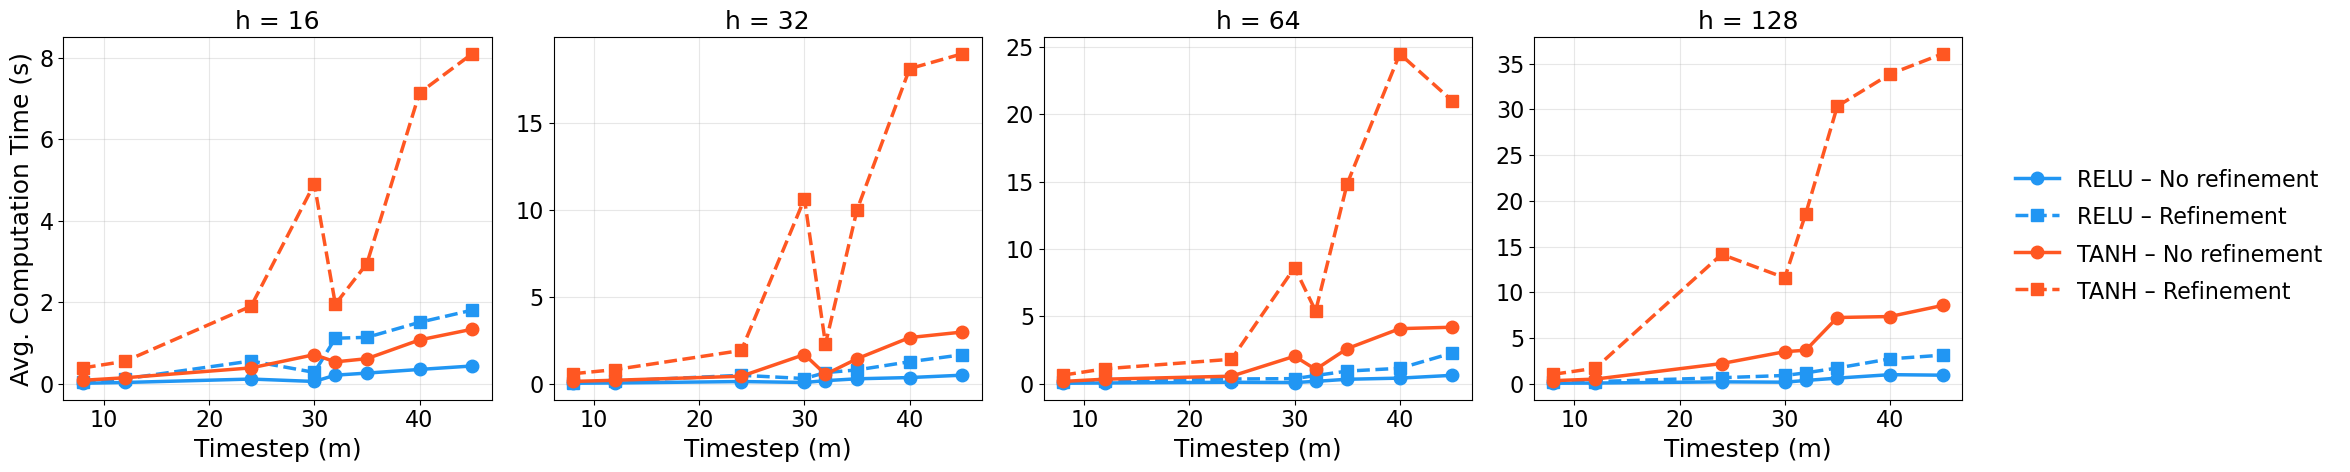

In [11]:
hidden_sizes = sorted(df['hidden_size'].unique())
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False) # 原(20, 5)
axes = axes.flatten()

for ax, h in zip(axes, hidden_sizes):
    sub = df[df['hidden_size'] == h].sort_values('time_step')
    for act in ['RELU', 'TANH']:
        s = sub[sub['activation'] == act.lower()]
        ax.plot(s['time_step'], s['timing_verify_robustness_avg_ms'] / 1000,
                color=ACT_COLOR[act], ls='-',  marker='o')
        ax.plot(s['time_step'], s['timing_recursive_split_verify_avg_ms'] / 1000,
                color=ACT_COLOR[act], ls='--', marker='s')
    ax.set_title(f'h = {h}')
    ax.set_xlabel('Timestep (m)')
    # ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Avg. Computation Time (s)', fontsize=FONT_LABEL)
# axes[2].set_ylabel('Avg. Computation Time (s) [log]')

legend_handles = [
    mlines.Line2D([], [], color=ACT_COLOR['RELU'], ls='-',  marker='o', label='RELU – No refinement'),
    mlines.Line2D([], [], color=ACT_COLOR['RELU'], ls='--', marker='s', label='RELU – Refinement'),
    mlines.Line2D([], [], color=ACT_COLOR['TANH'], ls='-',  marker='o', label='TANH – No refinement'),
    mlines.Line2D([], [], color=ACT_COLOR['TANH'], ls='--', marker='s', label='TANH – Refinement'),
]
# fig.legend(handles=legend_handles, loc='upper center', ncol=4,
#            bbox_to_anchor=(0.5, 0.02), fontsize=FONT_LEGEND)
# fig.text(-0.02, 0.5, 'Avg. Computation Time (s)',
#          va='center', ha='center', rotation='vertical', fontsize=FONT_LABEL)
fig.legend(handles=legend_handles, loc='center left', ncol=1,
           bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=FONT_LEGEND)

fig.tight_layout()
fig.savefig(OUT_DIR + 'fig1_m_scaling.pdf', bbox_inches='tight')
plt.show()

## 圖 3 — ZeroSplit Overhead Ratio

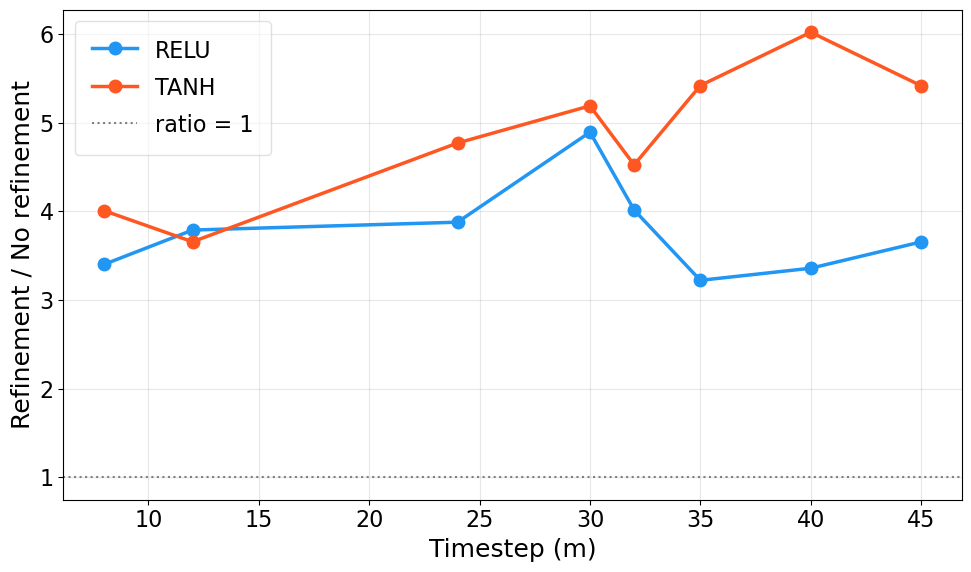

In [12]:
df['overhead_ratio'] = (df['timing_recursive_split_verify_avg_ms']
                        / df['timing_verify_robustness_avg_ms'])

agg_T = df.groupby(['time_step', 'activation'])['overhead_ratio'].mean().reset_index()

fig, ax = plt.subplots(figsize=FIG_SIZE)

for act in ['RELU', 'TANH']:
    s = agg_T[agg_T['activation'] == act.lower()].sort_values('time_step')
    ax.plot(s['time_step'], s['overhead_ratio'],
            color=ACT_COLOR[act], marker='o', label=act)

ax.axhline(1.0, color='gray', ls=':', lw=1.5, label='ratio = 1')
ax.set_xlabel('Timestep (m)')
ax.set_ylabel('Refinement / No refinement')
ax.legend(framealpha=0.6)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR + 'fig3_overhead_ratio.pdf', bbox_inches='tight')
plt.show()

## 圖 5 — SHAP Ranking Computation Time

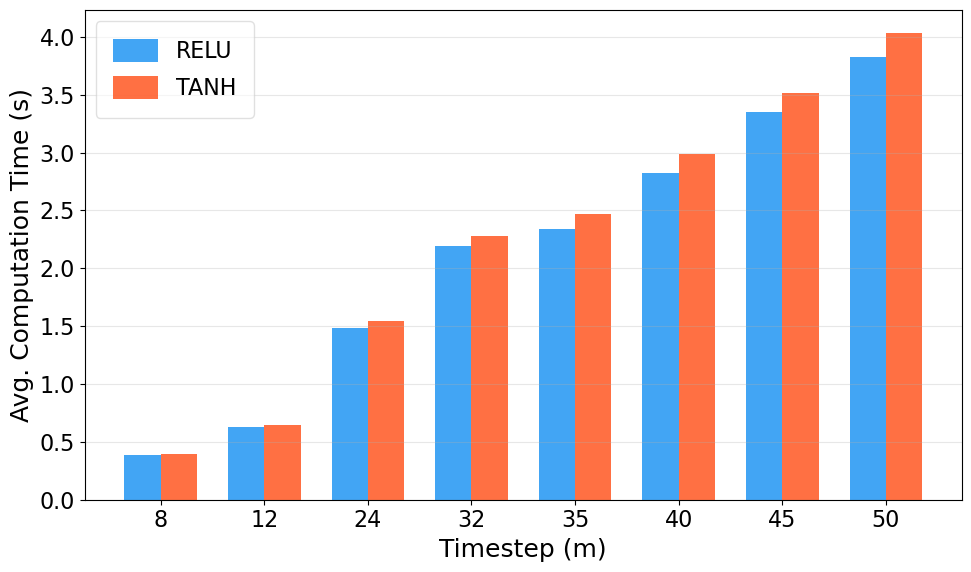

In [15]:
if SHAP_DATA is None:
    print('尚未找到 shap_timing_*.xlsx，請先執行 locate_timestep_shap.py')
else:
    shap_agg = (SHAP_DATA
                .groupby(['time_step', 'activation'])['avg_time_s'] #原: avg_time_s
                .mean()
                .reset_index())

    timesteps = sorted(shap_agg['time_step'].unique())
    x     = np.arange(len(timesteps))
    width = 0.35

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    for i, act in enumerate(['RELU', 'TANH']):
        vals = (shap_agg[shap_agg['activation'] == act.lower()]
                .sort_values('time_step')['avg_time_s'].values)
        ax.bar(x + i * width, vals, width,
               label=act, color=ACT_COLOR[act], alpha=0.85)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(timesteps)
    ax.set_xlabel('Timestep (m)')
    ax.set_ylabel('Avg. Computation Time (s)')
    ax.legend(loc='upper left', framealpha=0.6)
    ax.grid(True, alpha=0.3, axis='y')

    fig.tight_layout()
    fig.savefig(OUT_DIR + 'fig5_shap_timing.pdf', bbox_inches='tight')
    plt.show()

# GenBaB

In [ ]:
def to_set(s):
    """把逗號分隔的 index 字串轉成 int 的 set
    空字串或 NaN(該 eps 沒有任何此類樣本)回傳空 set。
    例: "11,27" -> {11, 27}；"" -> set()
    """
    if pd.isna(s) or s == '':
        return set()
    return {int(x) for x in str(s).split(',')}

def union_idx(series):
    """把一個 Series(同一 (hidden,ts) 底下、各 eps 的 idx 字串)
    全部轉 set 後做聯集 = 跨 eps 去重後的「不同樣本」集合。
    Early-stop:
    同一樣本在多個 eps 都出現,聯集後也只算一次。
    """
    out = set()
    for s in series.map(to_set):
        out |= s          # 累積聯集
    return out

def wavg_ms_to_s(values_ms, weights):
    """以 weights 加權平均 values_ms(毫秒),再轉秒。
    跳過 NaN 與 weight<=0 的列(該 eps 無失敗樣本);全無效回 NaN。
    """
    m = values_ms.notna() & (weights > 0)
    if not m.any():
        return float('nan')
    return (values_ms[m] * weights[m]).sum() / weights[m].sum() / 1000

def aggregate_per_config(df, eps_lo=0.01, eps_hi=0.30):
    rows = []
    sub = df[df['eps'].between(eps_lo, eps_hi)].copy()
    # 每列(每個 eps)的 CROWN-failed 子集大小 = 進 BaB 的樣本數,當 timing 權重
    sub['n_failed'] = sub['genbab_N'] - sub['genbab_crown_only']

    for (hs, ts), g in sub.groupby(['hidden', 'ts']):
        # ── 救援統計:idx 走跨 eps 去重聯集 ──
        rescued   = union_idx(g['rescued_sample_idx'])
        unknown   = union_idx(g['unknown_sample_idx'])
        unsafe    = union_idx(g['unsafe_sample_idx'])
        triggered = rescued | unknown | unsafe

        # 前提守護:救回的樣本不該又出現在 unknown/unsafe(否則 early-stop 等價性要重議)
        overlap = rescued & (unknown | unsafe)
        assert not overlap, (
            f"({hs},{ts}) 樣本 {overlap} 同時在 rescued 與 unknown/unsafe"
        )

        # ── 耗時統計:逐列(逐 eps)以 n_failed 加權,不可去重 ──
        # 兩條線都限定 CROWN-failed 子集,故共用同一組權重 n_failed
        crown_s = wavg_ms_to_s(g['genbab_avg_crown_ms'], g['n_failed'])
        bab_s   = wavg_ms_to_s(g['genbab_avg_bab_ms'],   g['n_failed'])

        rows.append({
            'hidden': hs, 'ts': ts,
            'n_triggered':  len(triggered),
            'n_rescued':    len(rescued),
            'n_unresolved': len(triggered - rescued),
            'success_rate': len(rescued) / len(triggered) if triggered else float('nan'),
            'crown_s': crown_s,   # 每個被 refine 樣本的平均 CROWN 階段耗時(秒)
            'bab_s':   bab_s,     # 每個被 refine 樣本的平均 BaB 階段耗時(秒)
        })

    return pd.DataFrame(rows)

agg_genbab = aggregate_per_config(GENBAB)

## 圖 8 — m scaling: POPQORN vs ZeroSplit (facet by hidden_size)

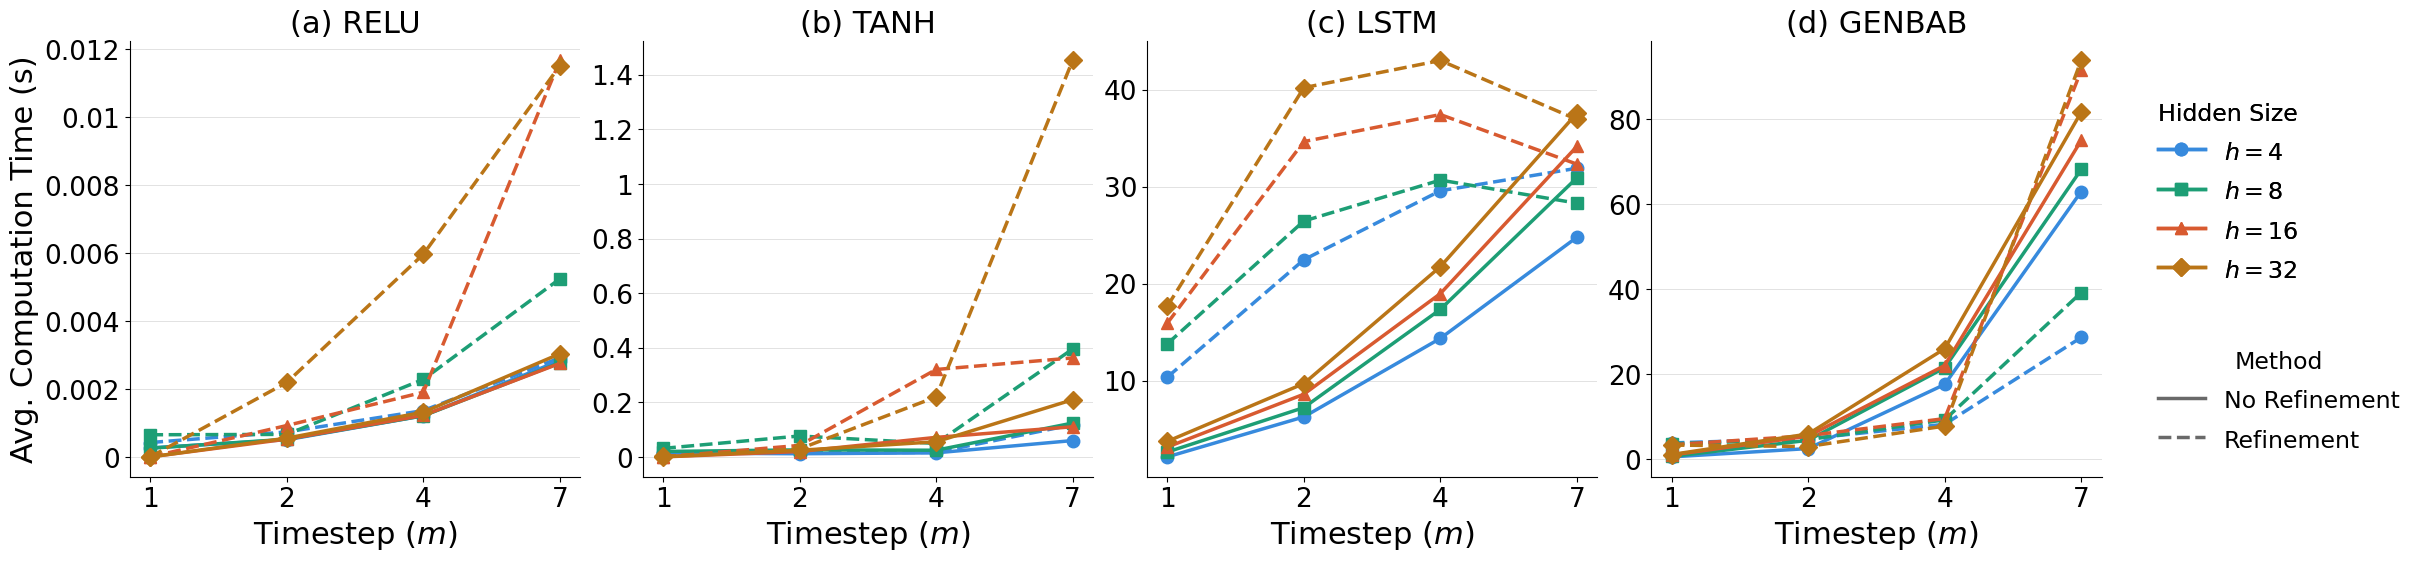

In [40]:
from matplotlib.lines import Line2D

# ── fig8 專用設定 ──────────────────────────────────────────────────────
H_VALS  = [4, 8, 16, 32]
H_COLOR = {4: '#378ADD', 8: '#1D9E75', 16: '#D85A30', 32: '#BA7517'}
H_MARK  = {4: 'o',       8: 's',       16: '^',       32: 'D'}

# 等距 x 位置
M_VALS = [1, 2, 4, 7]
M_POS  = {m: i for i, m in enumerate(M_VALS)}

# ── helper ─────────────────────────────────────────────────────────────
def plot_h_lines(ax, df, m_col, t_col_refine, t_col_norefine):
    for h in H_VALS:
        sub = df[df['hidden_size'] == h].sort_values(m_col)
        if sub.empty:
            continue
        x_pos = [M_POS[m] for m in sub[m_col]]
        # No Refinement (POPQORN): 實線
        ax.plot(x_pos, sub[t_col_norefine],
                color=H_COLOR[h], linestyle='-',
                marker=H_MARK[h],
                linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
        # Refinement (ZeroSplit): 虛線
        ax.plot(x_pos, sub[t_col_refine],
                color=H_COLOR[h], linestyle='--',
                marker=H_MARK[h],
                linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

# ── figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(21, 5.5), constrained_layout=True)

FONT_LABEL_8  = 22
FONT_TICK_8   = 19
FONT_LEGEND_8 = 17

# (a) ReLU
df_relu = df_rnn[df_rnn['activation'] == 'relu'].copy()
df_relu['timing_zs_total_avg_s'] = df_relu['timing_zs_total_avg_ms'] / 1000
df_relu['timing_popqorn_avg_s']  = df_relu['timing_popqorn_avg_ms']  / 1000
plot_h_lines(axes[0], df_relu, 'time_step',
             'timing_zs_total_avg_s', 'timing_popqorn_avg_s')
axes[0].set_title('(a) RELU')

# (b) Tanh
df_tanh = df_rnn[df_rnn['activation'] == 'tanh'].copy()
df_tanh['timing_zs_total_avg_s'] = df_tanh['timing_zs_total_avg_ms'] / 1000
df_tanh['timing_popqorn_avg_s']  = df_tanh['timing_popqorn_avg_ms']  / 1000
plot_h_lines(axes[1], df_tanh, 'time_step',
             'timing_zs_total_avg_s', 'timing_popqorn_avg_s')
axes[1].set_title('(b) TANH')

# (c) LSTM —— popqorn_avg_sec 已經是秒，不要再除
df_lstm_p = df_lstm.copy()
df_lstm_p['timing_zs_total_avg_s'] = df_lstm_p['timing_zs_total_avg_ms'] / 1000
plot_h_lines(axes[2], df_lstm_p, 'time_step',
             'timing_zs_total_avg_s', 'popqorn_avg_sec')
axes[2].set_title('(c) LSTM')

# (d) GenBaB —— agg_genbab 欄位為 hidden/ts/crown_s/bab_s，已是秒，不需除 1000
#     沿用同樣線型約定：實線 = No Refinement = crown_s，虛線 = Refinement = bab_s
for h in H_VALS:
    sub = agg_genbab[agg_genbab['hidden'] == h].sort_values('ts')
    if sub.empty:
        continue
    x_pos = [M_POS[m] for m in sub['ts']]
    # No Refinement (CROWN only): 實線
    axes[3].plot(x_pos, sub['crown_s'],
                 color=H_COLOR[h], linestyle='-',
                 marker=H_MARK[h],
                 linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
    # Refinement (BaB): 虛線
    axes[3].plot(x_pos, sub['bab_s'],
                 color=H_COLOR[h], linestyle='--',
                 marker=H_MARK[h],
                 linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
axes[3].set_title('(d) GENBAB')

# ── 共用格式 ────────────────────────────────────────────────────────────
for ax in axes:
    ax.set_xlabel('Timestep ($m$)', fontsize=FONT_LABEL_8)
    ax.set_xticks(list(range(len(M_VALS))))
    ax.set_xticklabels([str(m) for m in M_VALS])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3g'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linewidth=0.6, color='#dddddd', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=FONT_TICK_8)
    ax.title.set_fontsize(FONT_LABEL_8)

axes[0].set_ylabel('Avg. Computation Time (s)', fontsize=FONT_LABEL_8)
for ax in axes[1:]:
    ax.set_ylabel('')

# ── Legend: 兩段式（Hidden Size + Method）─────────────────────────────
hidden_handles = [
    Line2D([0], [0], color=H_COLOR[h], marker=H_MARK[h],
           linestyle='-', linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
           label=f'$h={h}$')
    for h in H_VALS
]

method_handles = [
    Line2D([0], [0], color='dimgray', linestyle='-',
           linewidth=LINE_WIDTH, label='No Refinement'),
    Line2D([0], [0], color='dimgray', linestyle='--',
           linewidth=LINE_WIDTH, label='Refinement'),
]

leg1 = fig.legend(handles=hidden_handles,
                  loc='center left', bbox_to_anchor=(1.01, 0.66),
                  frameon=False, title='Hidden Size',
                  title_fontsize=FONT_LEGEND_8, fontsize=FONT_LEGEND_8)
fig.add_artist(leg1)
fig.legend(handles=method_handles,
           loc='center left', bbox_to_anchor=(1.01, 0.28),
           frameon=False, title='Method',
           title_fontsize=FONT_LEGEND_8, fontsize=FONT_LEGEND_8)

fig.savefig(OUT_DIR + 'fig8.pdf', bbox_inches='tight', dpi=300)
fig.savefig(OUT_DIR + 'fig8.png', bbox_inches='tight', dpi=300)
plt.show()